In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [19]:
xlsx=pd.ExcelFile("heart_disease.xlsx")
xlsx.sheet_names

['Description', 'Heart_disease']

In [20]:
df=pd.read_excel('heart_disease.xlsx',sheet_name='Heart_disease')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


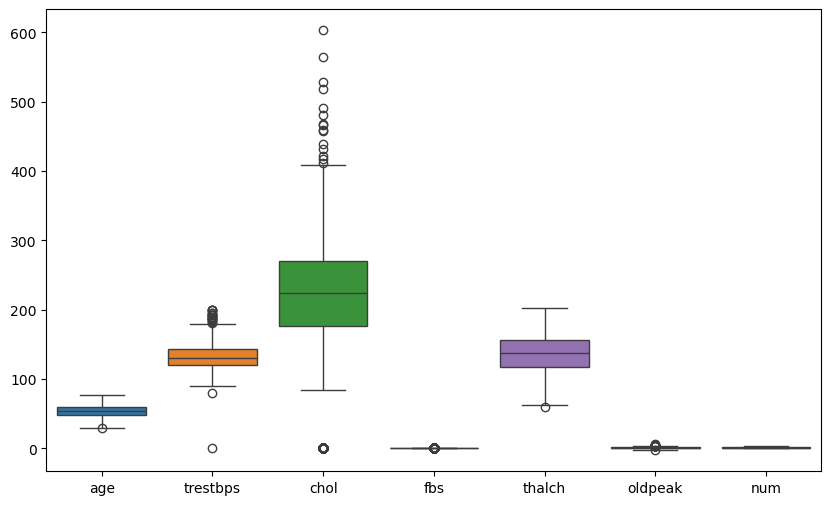

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(df)
plt.show()

In [22]:
df.shape

(908, 13)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [24]:
print(df.isnull().sum())

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


In [26]:
oldpeak_median = df['oldpeak'].median()

In [27]:
 df['oldpeak']= df['oldpeak'].fillna(oldpeak_median)

In [28]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64


In [32]:
df.duplicated().sum()

np.int64(1)

In [33]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
print("Categorical columns:", categorical_cols.tolist())

Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [36]:
# Encode categorical variables
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [37]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,1,2.3,0,0,0
1,41,1,1,135,203,0,1,132,1,0.0,1,0,0
2,57,1,0,140,192,0,1,148,1,0.4,1,0,0
3,52,1,3,118,186,0,0,190,1,0.0,1,0,0
4,57,1,0,110,201,0,1,126,3,1.5,1,0,0


In [38]:
df1=df.copy()

In [39]:
df['num'].unique()

array([0, 1, 2, 3, 4])

In [41]:
x=df.iloc[:,:-1]

In [43]:
y=df.iloc[:,-1]

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((725, 12), (182, 12), (725,), (182,))

In [46]:
dtree=DecisionTreeClassifier(max_depth=6,max_leaf_nodes=10,criterion='entropy')
dtree.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6, max_leaf_nodes=10)

In [47]:
def evaluate_cif(y,yhat):
    cm=confusion_matrix(y,yhat)
    plt.figure(figsize=(6,3))
    sns.heatmap(cm,annot=True,fmt='d',cbar=False,cmap='mako')
    plt.show()
    print(classification_report(y,yhat))

In [48]:
yhat_train=dtree.predict(x_train)

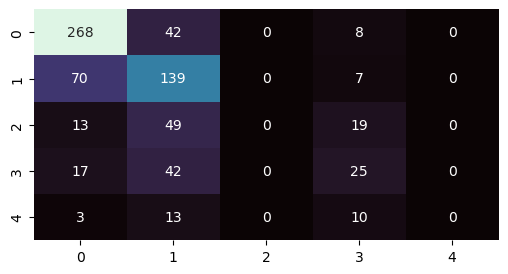

              precision    recall  f1-score   support

           0       0.72      0.84      0.78       318
           1       0.49      0.64      0.55       216
           2       0.00      0.00      0.00        81
           3       0.36      0.30      0.33        84
           4       0.00      0.00      0.00        26

    accuracy                           0.60       725
   macro avg       0.31      0.36      0.33       725
weighted avg       0.50      0.60      0.54       725



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [49]:
evaluate_cif(y_train,yhat_train)

In [50]:
yhat_test=dtree.predict(x_test)

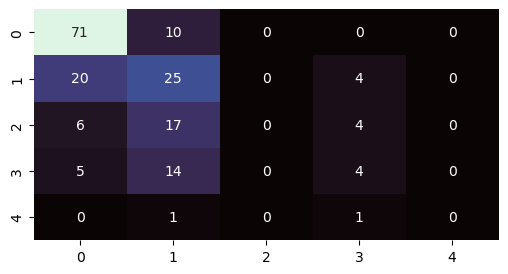

              precision    recall  f1-score   support

           0       0.70      0.88      0.78        81
           1       0.37      0.51      0.43        49
           2       0.00      0.00      0.00        27
           3       0.31      0.17      0.22        23
           4       0.00      0.00      0.00         2

    accuracy                           0.55       182
   macro avg       0.28      0.31      0.29       182
weighted avg       0.45      0.55      0.49       182



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
evaluate_cif(y_test,yhat_test)

In [52]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid search with cross-validation
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)


Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best Accuracy: 0.5627586206896552


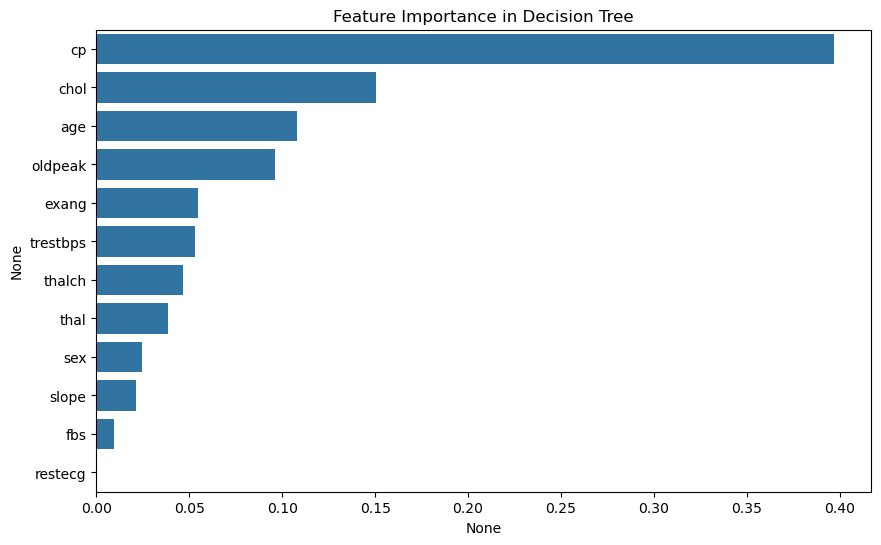

In [54]:
# Feature importance plot
importances = grid_search.best_estimator_.feature_importances_
feat_imp = pd.Series(importances, index=x.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title('Feature Importance in Decision Tree')
plt.show()


#### Common hyperparameters of Decision Tree models and their effects:

###### Decision Trees have several important hyperparameters that control their complexity and performance. The max_depth parameter limits how deep the tree can grow — a smaller value prevents overfitting. The min_samples_split defines the minimum number of samples required to split a node; increasing it makes the model more general and less prone to overfitting. The min_samples_leaf sets the minimum samples needed in a leaf node, which helps smooth predictions. The criterion parameter (like gini, entropy, or log_loss) determines how the model measures the quality of a split. Lastly, max_features controls how many features are considered when looking for the best split, helping manage variance and randomness in the model.

#### Difference between Label Encoding and One-Hot Encoding:

###### Label Encoding converts categorical text values into numeric labels, for example, Red → 0, Blue → 1, Green → 2. However, this can unintentionally create an ordinal relationship between categories, which may mislead the model. One-Hot Encoding, on the other hand, creates separate binary columns for each category, such as Red → [1,0,0], Blue → [0,1,0]. This avoids implying any order between categories but can increase the dataset’s dimensionality if there are many unique values.